## OASIS3 Cohort


Load all 83k parcels from all subjects and split the first analysis in 26 regions

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns

PROJECT_ROOT = next(
    folder for folder in (Path.cwd(), *Path.cwd().parents)
    if (folder / "data" / "database_finale_labels_corrette.csv").is_file()
)
DATA_FILE = PROJECT_ROOT / "data" / "database_finale_labels_corrette.csv"
SPLITS_FILE = PROJECT_ROOT / "data" / "splits.json"
MEANS_MEDIANS_DIR = PROJECT_ROOT / "outputs" / "cohorts" / "oasis3" / "runs" / "connected-atlas-8cf3dc8f" / "parcel_vectors"
RESULTS_DIR = PROJECT_ROOT / "outputs" / "cohorts" / "oasis3" / "runs" / "connected-atlas-8cf3dc8f" / "statistics"
LABEL_LOOKUP_DIR = PROJECT_ROOT / "docs" / "label_lookup.csv" 

WEIGHTED_DEGREE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "cohorts"
    / "oasis3"
    / "runs"
    / "connected-atlas-8cf3dc8f"
    / "graphs"
    / "unthresholded"
    / "was"
    / "expW"
)


In [2]:
# Load the heuristic splits from the JSON file
subject_dirs = {
    folder.name: folder
    for folder in MEANS_MEDIANS_DIR.glob("sub-*")
    if all(
        (folder / name).is_file()
        for name in (
            "direct_mean.dat",
            "direct_median.dat",
            "parcel_order.txt",
            "complete.json",
        )
    )
}

splits = json.loads(SPLITS_FILE.read_text())

test_healthy = {
    f"sub-{str(item).removeprefix('sub-')}"
    for item in splits["test_healthy"]
}

test_unhealthy = {
    f"sub-{str(item).removeprefix('sub-')}"
    for item in splits["test_unhealthy"]
}

if test_healthy & test_unhealthy:
    raise ValueError("Healthy and Unhealthy test cohorts overlap")

selected_healthy = sorted(test_healthy & subject_dirs.keys())
selected_unhealthy = sorted(test_unhealthy & subject_dirs.keys())

print("Healthy subjects found:", len(selected_healthy))
print("Unhealthy subjects found:", len(selected_unhealthy))

Healthy subjects found: 137
Unhealthy subjects found: 130


In [3]:
print(selected_healthy)
print(selected_unhealthy)

['sub-0002', 'sub-0003', 'sub-0010', 'sub-0014', 'sub-0055', 'sub-0067', 'sub-0077', 'sub-0090', 'sub-0092', 'sub-0093', 'sub-0097', 'sub-0125', 'sub-0138', 'sub-0143', 'sub-0146', 'sub-0155', 'sub-0174', 'sub-0232', 'sub-0246', 'sub-0251', 'sub-0291', 'sub-0310', 'sub-0328', 'sub-0348', 'sub-0351', 'sub-0356', 'sub-0363', 'sub-0372', 'sub-0387', 'sub-0395', 'sub-0431', 'sub-0432', 'sub-0443', 'sub-0458', 'sub-0476', 'sub-0485', 'sub-0490', 'sub-0508', 'sub-0509', 'sub-0531', 'sub-0535', 'sub-0540', 'sub-0542', 'sub-0550', 'sub-0551', 'sub-0566', 'sub-0571', 'sub-0594', 'sub-0595', 'sub-0620', 'sub-0625', 'sub-0643', 'sub-0644', 'sub-0658', 'sub-0671', 'sub-0680', 'sub-0691', 'sub-0694', 'sub-0701', 'sub-0710', 'sub-0711', 'sub-0727', 'sub-0728', 'sub-0730', 'sub-0747', 'sub-0759', 'sub-0769', 'sub-0780', 'sub-0792', 'sub-0800', 'sub-0801', 'sub-0808', 'sub-0835', 'sub-0844', 'sub-0858', 'sub-0887', 'sub-0950', 'sub-0958', 'sub-0979', 'sub-0980', 'sub-0992', 'sub-1021', 'sub-1034', 'su

In [4]:
# Loop over the ROIs regions and extract statistics for each region
label_lookup = pd.read_csv(LABEL_LOOKUP_DIR)
label_lookup


,label_number,label_name,roi_id_start,roi_id_end,parcel_count
0,3,Left cerebral cortex,0,23290,23291
1,4,Left lateral ventricle,23291,23884,594
2,5,Left inferior lateral ventricle,23885,23915,31
3,8,Left cerebellum cortex,23916,28778,4863
4,10,Left thalamus,28779,29443,665
5,11,Left caudate,29444,29803,360
6,12,Left putamen,29804,30309,506
7,13,Left pallidum,30310,30452,143
8,16,Brain-stem,30453,32445,1993
9,17,Left hippocampus,32446,32801,356


In [5]:
df_stats_results = pd.DataFrame(columns=[
    "roi",
    "t_stat",
    "t_p_value",
    "u_stat_on_regional_means",
    "u_p_value_on_regional_means",
])

Loop over selected subjects from the split.json file and extract each ROI mean and median values from the jacobian logs.

In [6]:
# Collect one regional mean and median per subject and ROI
rois = label_lookup["label_number"].astype(int).tolist()

# Prepare dictionaries to hold mean and median values for healthy and unhealthy subjects
mean_values_healthy = {roi: [] for roi in rois}
mean_values_unhealthy = {roi: [] for roi in rois}
median_values_healthy = {roi: [] for roi in rois}
median_values_unhealthy = {roi: [] for roi in rois}

# Loop over selected subjects and extract regional means and medians for each ROI
for subject_name in selected_healthy + selected_unhealthy:
    
    subject = subject_dirs[subject_name]

    # Read the mean, median, and parcel offsets data for the subject
    means = np.fromfile(subject / "direct_mean.dat", dtype=np.float64)
    medians = np.fromfile(subject / "direct_median.dat", dtype=np.float64)
    offsets = np.fromfile(subject / "parcel_offsets.dat", dtype=np.int64)
    parcel_sizes = np.diff(offsets)

    # Loop over the ROIs and compute regional means and medians
    for row in label_lookup.itertuples(index=False):

        # Extract the ROI information from the label lookup and indexes
        roi = int(row.label_number)
        start = int(row.roi_id_start)
        end = int(row.roi_id_end)

        # Extract the mean and median values for the current ROI using the start and end indexes        
        selected_means = means[start:end + 1]
        selected_medians = medians[start:end + 1]
        selected_sizes = parcel_sizes[start:end + 1]

        # Compute the regional mean and median for the current ROI using the selected mean and median values
        regional_mean = np.average(selected_means, weights=selected_sizes)
        regional_median = np.median(selected_medians)

        # Store the regional mean and median in the appropriate dictionaries
        if subject_name in test_healthy:
            mean_values_healthy[roi].append(regional_mean)
            median_values_healthy[roi].append(regional_median)
        else:
            mean_values_unhealthy[roi].append(regional_mean)
            median_values_unhealthy[roi].append(regional_median)


In [7]:
stats_results = []
label_names = label_lookup.set_index("label_number")["label_name"].to_dict()

# Loop over the ROIs and perform statistical tests
for roi in rois:
    mean_healthy = np.asarray(mean_values_healthy[roi])
    mean_unhealthy = np.asarray(mean_values_unhealthy[roi])

    t_stat, t_p_value = stats.ttest_ind(
        mean_unhealthy,
        mean_healthy,
        equal_var=False,
        alternative="two-sided",
    )

    # Rank-based sensitivity test on the same subject-level regional
    # voxel-weighted means used by the Welch test above.
    u_stat, u_p_value = stats.mannwhitneyu(
        mean_unhealthy,
        mean_healthy,
        alternative="two-sided",
    )

    # Calculate Hedges' g: Unhealthy minus Healthy
    healthy_variance = np.var(mean_healthy, ddof=1)
    unhealthy_variance = np.var(mean_unhealthy, ddof=1)

    pooled_sd = np.sqrt(
        (
            (len(mean_healthy) - 1) * healthy_variance
            + (len(mean_unhealthy) - 1) * unhealthy_variance
        )
        / (len(mean_healthy) + len(mean_unhealthy) - 2)
    )

    cohens_d = (
        np.mean(mean_unhealthy) - np.mean(mean_healthy)
    ) / pooled_sd

    hedges_correction = (
        1
        - 3
        / (
            4 * (len(mean_healthy) + len(mean_unhealthy))
            - 9
        )
    )

    hedges_g = cohens_d * hedges_correction

    stats_results.append({
        "roi": roi,
        "label_name": label_names[roi],
        "healthy_n": len(mean_healthy),
        "unhealthy_n": len(mean_unhealthy),
        "healthy_regional_mean": np.mean(mean_healthy),
        "unhealthy_regional_mean": np.mean(mean_unhealthy),
        "mean_difference_unhealthy_minus_healthy": (
            np.mean(mean_unhealthy)
            - np.mean(mean_healthy)
        ),
        "hedges_g_unhealthy_minus_healthy": hedges_g,
        "t_stat": t_stat,
        "t_p_value": t_p_value,
        "u_stat_on_regional_means": u_stat,
        "u_p_value_on_regional_means": u_p_value,
    })

df_stats_results = pd.DataFrame(stats_results)

df_stats_results["t_q_bh"] = multipletests(
    df_stats_results["t_p_value"],
    method="fdr_bh",
)[1]

df_stats_results["u_q_bh_on_regional_means"] = multipletests(
    df_stats_results["u_p_value_on_regional_means"],
    method="fdr_bh",
)[1]

df_stats_results["t_survives_fdr"] = (
    df_stats_results["t_q_bh"] < 0.05
)

df_stats_results["u_on_regional_means_survives_fdr"] = (
    df_stats_results["u_q_bh_on_regional_means"] < 0.05
)

df_stats_results.sort_values("t_q_bh")

,roi,label_name,healthy_n,unhealthy_n,healthy_regional_mean,unhealthy_regional_mean,mean_difference_unhealthy_minus_healthy,hedges_g_unhealthy_minus_healthy,t_stat,t_p_value,u_stat_on_regional_means,u_p_value_on_regional_means,t_q_bh,u_q_bh_on_regional_means,t_survives_fdr,u_on_regional_means_survives_fdr
16,44,Right inferior lateral ventricle,137,130,-0.211510,-0.053988,0.157522,0.618912,5.023082,0.000001,11823.0,0.000004,0.000027,0.000097,True,True
2,5,Left inferior lateral ventricle,137,130,-0.149726,-0.024449,0.125277,0.514045,4.169199,0.000044,11332.0,0.000119,0.000567,0.001034,True,True
20,51,Right putamen,137,130,-0.055855,-0.105054,-0.049198,-0.451413,-3.688118,0.000275,6682.0,0.000425,0.002385,0.002763,True,True
1,4,Left lateral ventricle,137,130,0.408289,0.622807,0.214518,0.441174,3.594883,0.000391,11354.0,0.000103,0.002541,0.001034,True,True
6,12,Left putamen,137,130,-0.078586,-0.123433,-0.044847,-0.430018,-3.510168,0.000529,6847.0,0.001105,0.002750,0.004788,True,True
18,49,Right thalamus,137,130,-0.098706,-0.136912,-0.038206,-0.409038,-3.336813,0.000974,6763.0,0.000685,0.004221,0.003562,True,True
4,10,Left thalamus,137,130,-0.113743,-0.146930,-0.033187,-0.382402,-3.132257,0.001930,6958.0,0.002026,0.007168,0.006585,True,True
15,43,Right lateral ventricle,137,130,0.407673,0.593630,0.185957,0.378000,3.082368,0.002281,10867.0,0.001870,0.007413,0.006585,True,True
12,26,Left accumbens area,137,130,-0.175149,-0.222555,-0.047406,-0.352545,-2.877891,0.004340,7178.0,0.006190,0.012539,0.016095,True,True
10,18,Left amygdala,137,130,0.034357,-0.000337,-0.034694,-0.337201,-2.732998,0.006784,7530.0,0.029302,0.017639,0.057553,True,False


In [8]:
df_stats_results.sort_values("t_q_bh")

,roi,label_name,healthy_n,unhealthy_n,healthy_regional_mean,unhealthy_regional_mean,mean_difference_unhealthy_minus_healthy,hedges_g_unhealthy_minus_healthy,t_stat,t_p_value,u_stat_on_regional_means,u_p_value_on_regional_means,t_q_bh,u_q_bh_on_regional_means,t_survives_fdr,u_on_regional_means_survives_fdr
16,44,Right inferior lateral ventricle,137,130,-0.211510,-0.053988,0.157522,0.618912,5.023082,0.000001,11823.0,0.000004,0.000027,0.000097,True,True
2,5,Left inferior lateral ventricle,137,130,-0.149726,-0.024449,0.125277,0.514045,4.169199,0.000044,11332.0,0.000119,0.000567,0.001034,True,True
20,51,Right putamen,137,130,-0.055855,-0.105054,-0.049198,-0.451413,-3.688118,0.000275,6682.0,0.000425,0.002385,0.002763,True,True
1,4,Left lateral ventricle,137,130,0.408289,0.622807,0.214518,0.441174,3.594883,0.000391,11354.0,0.000103,0.002541,0.001034,True,True
6,12,Left putamen,137,130,-0.078586,-0.123433,-0.044847,-0.430018,-3.510168,0.000529,6847.0,0.001105,0.002750,0.004788,True,True
18,49,Right thalamus,137,130,-0.098706,-0.136912,-0.038206,-0.409038,-3.336813,0.000974,6763.0,0.000685,0.004221,0.003562,True,True
4,10,Left thalamus,137,130,-0.113743,-0.146930,-0.033187,-0.382402,-3.132257,0.001930,6958.0,0.002026,0.007168,0.006585,True,True
15,43,Right lateral ventricle,137,130,0.407673,0.593630,0.185957,0.378000,3.082368,0.002281,10867.0,0.001870,0.007413,0.006585,True,True
12,26,Left accumbens area,137,130,-0.175149,-0.222555,-0.047406,-0.352545,-2.877891,0.004340,7178.0,0.006190,0.012539,0.016095,True,True
10,18,Left amygdala,137,130,0.034357,-0.000337,-0.034694,-0.337201,-2.732998,0.006784,7530.0,0.029302,0.017639,0.057553,True,False


In [9]:
# COunt how many ROIs survive FDR correction for each test
t_survives_count = df_stats_results["t_survives_fdr"].sum()
u_survives_count = df_stats_results["u_on_regional_means_survives_fdr"].sum()

print(f"ROIs surviving FDR correction (t-test): {t_survives_count}")
print(f"ROIs surviving FDR correction (Mann-Whitney U test): {u_survives_count}")

ROIs surviving FDR correction (t-test): 14
ROIs surviving FDR correction (Mann-Whitney U test): 12


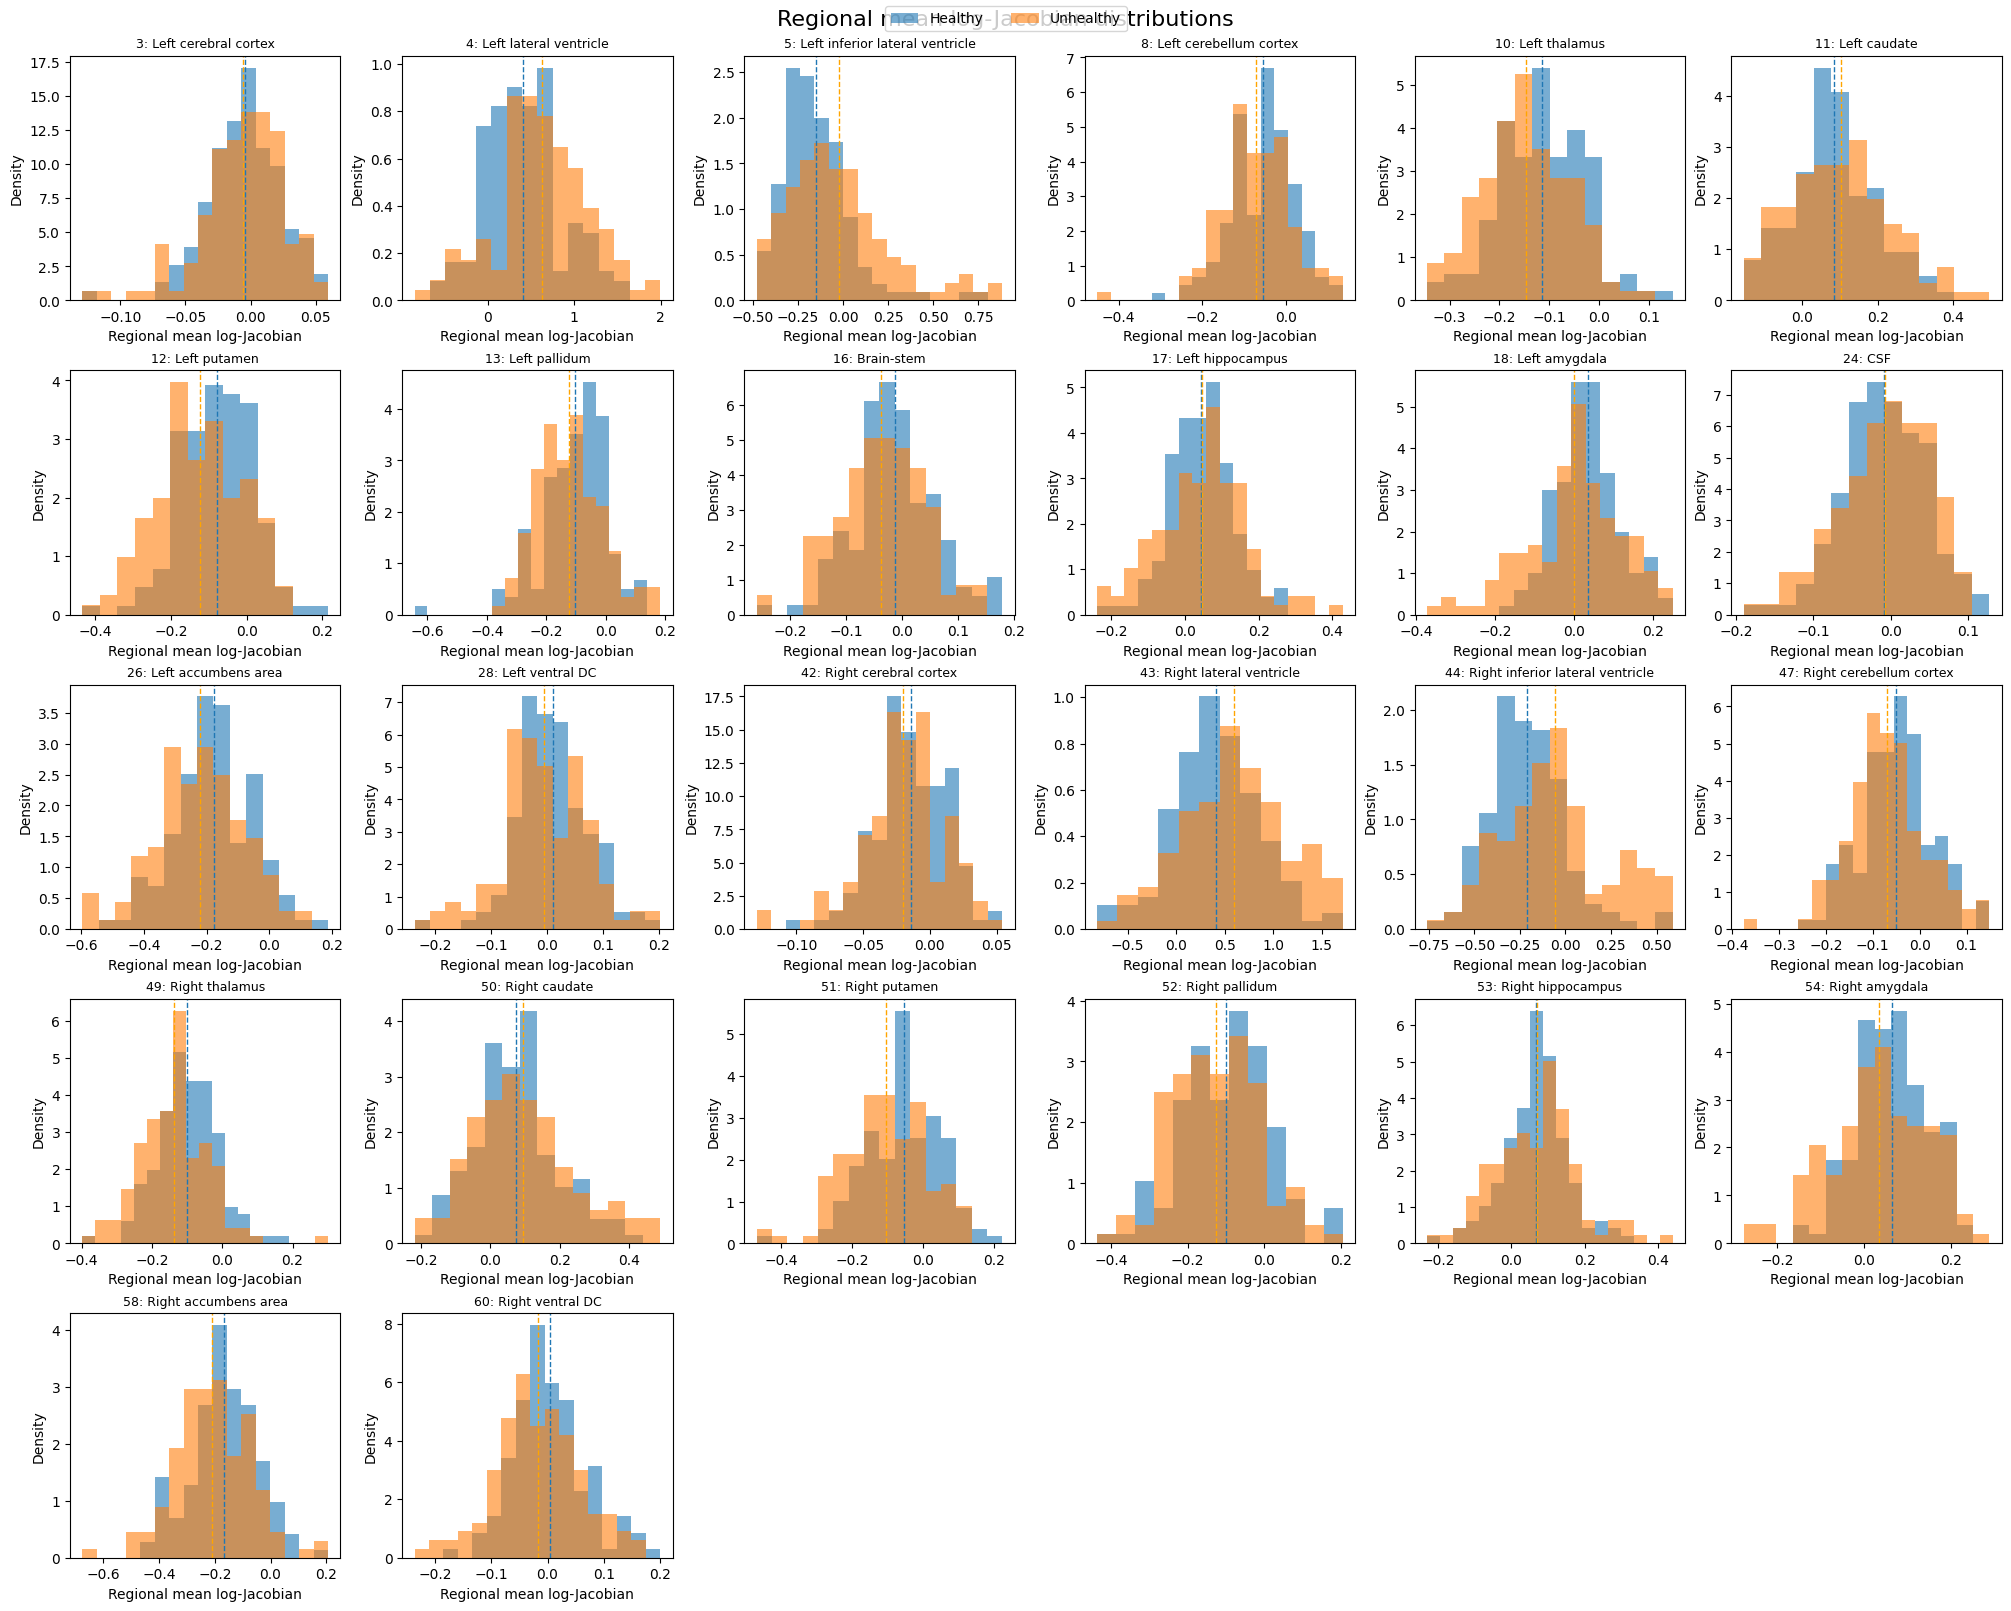

In [10]:
# Plot each ROI distribution of Jacobian mean values for Healthy vs Unhealthy

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    5,
    6,
    figsize=(20, 16),
    constrained_layout=True,
)

axes = axes.flatten()

for axis, roi in zip(axes, rois):
    healthy_values = mean_values_healthy[roi]
    unhealthy_values = mean_values_unhealthy[roi]

    label_name = label_lookup.loc[
        label_lookup["label_number"] == roi,
        "label_name",
    ].iloc[0]

    # Use identical Freedman-Diaconis bin boundaries for both groups
    combined_values = np.concatenate([
        healthy_values,
        unhealthy_values,
    ])
    common_bins = np.histogram_bin_edges(
        combined_values,
        bins="fd",
    )

    axis.hist(
        healthy_values,
        bins=common_bins,
        density=True,
        alpha=0.6,
        label="Healthy",
    )

    axis.hist(
        unhealthy_values,
        bins=common_bins,
        density=True,
        alpha=0.6,
        label="Unhealthy",
    )

    axis.axvline(
        np.mean(healthy_values),
        linestyle="--",
        linewidth=1,
    )

    axis.axvline(
        np.mean(unhealthy_values),
        linestyle="--",
        linewidth=1,
        color="orange",
    )

    axis.set_title(f"{roi}: {label_name}", fontsize=9)
    axis.set_xlabel("Regional mean log-Jacobian")
    axis.set_ylabel("Density")

# Hide the four unused panels
for axis in axes[len(rois):]:
    axis.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
)

fig.suptitle(
    "Regional mean log-Jacobian distributions",
    fontsize=16,
)

plt.show()

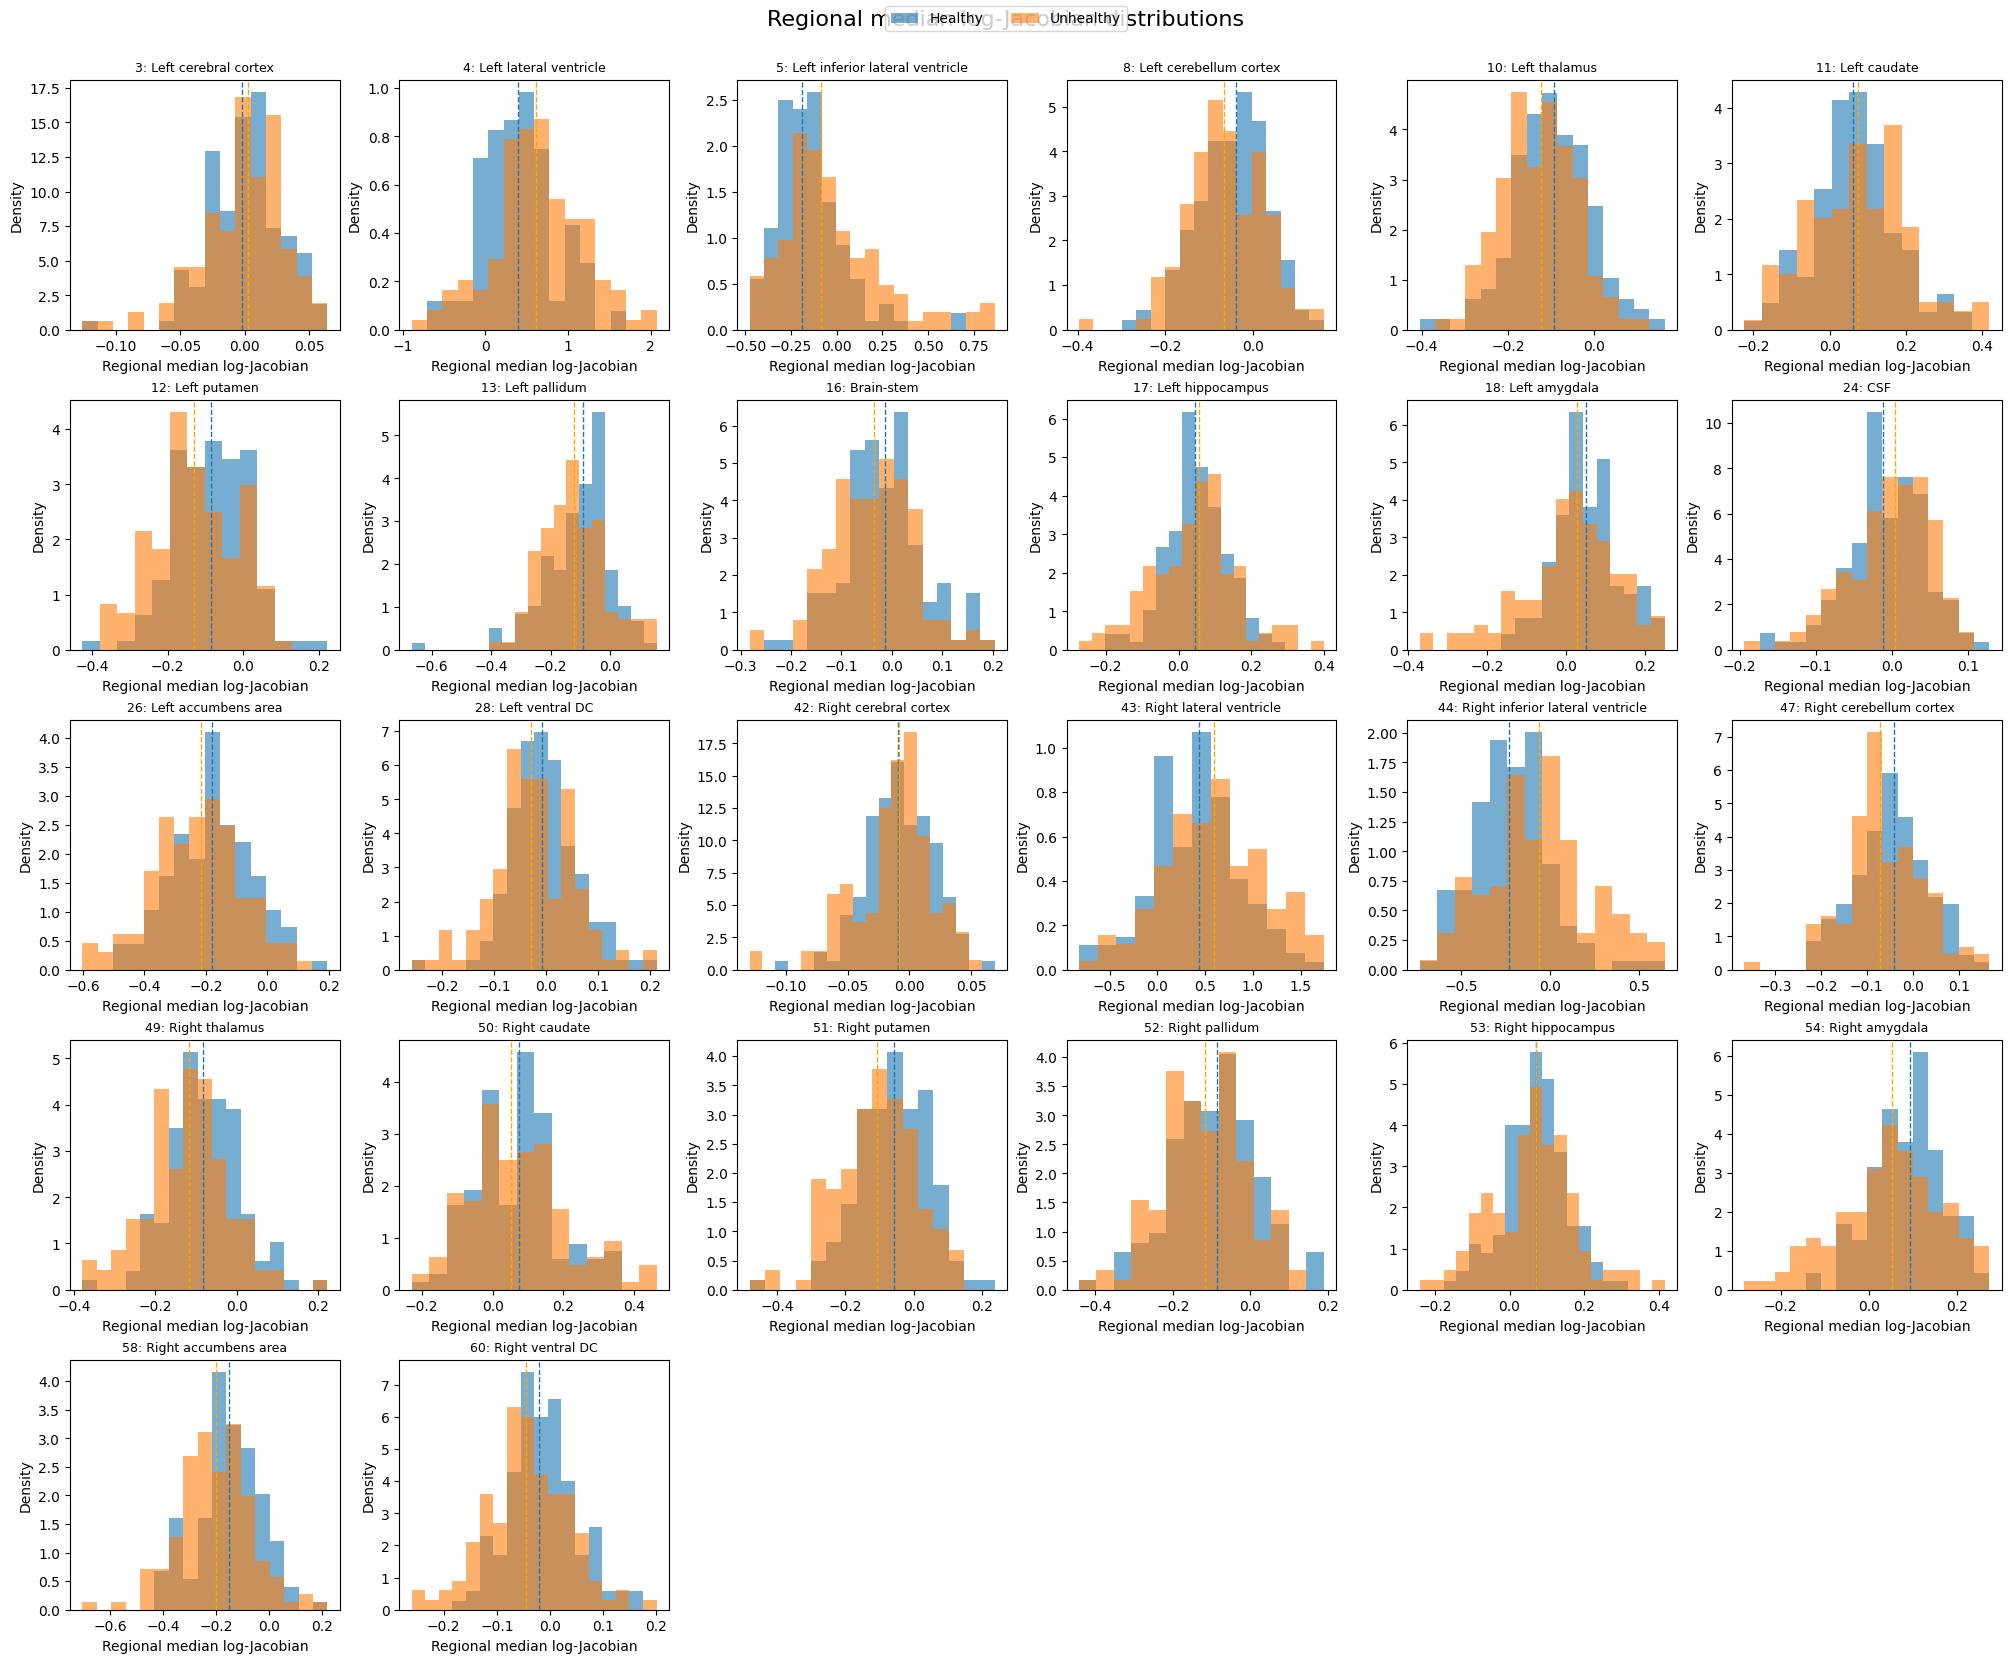

In [11]:
# Plot each ROI distribution of Jacobian median values for Healthy vs Unhealthy

fig, axes = plt.subplots(
    5,
    6,
    figsize=(20, 16),
    constrained_layout=True,
)

axes = axes.flatten()

for axis, roi in zip(axes, rois):
    healthy_values = median_values_healthy[roi]
    unhealthy_values = median_values_unhealthy[roi]

    label_name = label_lookup.loc[
        label_lookup["label_number"] == roi,
        "label_name",
    ].iloc[0]

    # Use identical Freedman-Diaconis bin boundaries for both groups
    combined_values = np.concatenate([
        healthy_values,
        unhealthy_values,
    ])
    common_bins = np.histogram_bin_edges(
        combined_values,
        bins="fd",
    )

    axis.hist(
        healthy_values,
        bins=common_bins,
        density=True,
        alpha=0.6,
        label="Healthy",
    )

    axis.hist(
        unhealthy_values,
        bins=common_bins,
        density=True,
        alpha=0.6,
        label="Unhealthy",
    )

    axis.axvline(
        np.median(healthy_values),
        linestyle="--",
        linewidth=1,
    )

    axis.axvline(
        np.median(unhealthy_values),
        linestyle="--",
        linewidth=1,
        color="orange",
    )

    axis.set_title(f"{roi}: {label_name}", fontsize=9)
    axis.set_xlabel("Regional median log-Jacobian")
    axis.set_ylabel("Density")

# Hide the four unused panels
for axis in axes[len(rois):]:
    axis.axis("off")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
)

fig.suptitle(
    "Regional median log-Jacobian distributions",
    fontsize=16,
    y=1.03,
)

plt.show()

In [12]:
# Collect one voxel-weighted regional weighted-degree mean per subject and ROI

weighted_degree_mean_healthy = {roi: [] for roi in rois}
weighted_degree_mean_unhealthy = {roi: [] for roi in rois}

# Loop over selected subjects
for subject_name in selected_healthy + selected_unhealthy:
    graph_subject = WEIGHTED_DEGREE_DIR / subject_name
    parcel_subject = MEANS_MEDIANS_DIR / subject_name

    # Read weighted degree and parcel sizes
    weighted_degree = np.fromfile(
        graph_subject / "weighted_degree.dat",
        dtype=np.float64,
    )

    offsets = np.fromfile(
        parcel_subject / "parcel_offsets.dat",
        dtype=np.int64,
    )

    parcel_sizes = np.diff(offsets)

    # Loop over the 26 ROIs
    for row in label_lookup.itertuples(index=False):
        roi = int(row.label_number)
        start = int(row.roi_id_start)
        end = int(row.roi_id_end)

        selected_weighted_degree = weighted_degree[start:end + 1]
        selected_sizes = parcel_sizes[start:end + 1]

        # Voxel-weighted regional mean
        regional_weighted_degree_mean = np.average(
            selected_weighted_degree,
            weights=selected_sizes,
        )

        if subject_name in test_healthy:
            weighted_degree_mean_healthy[roi].append(
                regional_weighted_degree_mean
            )
        else:
            weighted_degree_mean_unhealthy[roi].append(
                regional_weighted_degree_mean
            )

In [13]:
stats_results_weighted_degree = []
label_names = label_lookup.set_index("label_number")["label_name"].to_dict()

# Loop over the ROIs and perform statistical tests
for roi in rois:
    mean_weighted_degree_healthy = weighted_degree_mean_healthy[roi]
    mean_weighted_degree_unhealthy = weighted_degree_mean_unhealthy[roi]
    t_stat, t_p_value = stats.ttest_ind(
        mean_weighted_degree_unhealthy,
        mean_weighted_degree_healthy,
        equal_var=False,
        alternative="two-sided",
    )
    # Rank-based sensitivity test on the same subject-level regional
    # voxel-weighted means used by the Welch test above.
    u_stat, u_p_value = stats.mannwhitneyu(
        mean_weighted_degree_unhealthy,
        mean_weighted_degree_healthy,
        alternative="two-sided",
    )

    healthy_variance = np.var(mean_weighted_degree_healthy, ddof=1)
    unhealthy_variance = np.var(mean_weighted_degree_unhealthy, ddof=1)
    pooled_sd = np.sqrt(
        (
            (len(mean_weighted_degree_healthy) - 1) * healthy_variance
            + (len(mean_weighted_degree_unhealthy) - 1) * unhealthy_variance
        )
        / (
            len(mean_weighted_degree_healthy)
            + len(mean_weighted_degree_unhealthy)
            - 2
        )
    )
    cohens_d = (
        np.mean(mean_weighted_degree_unhealthy)
        - np.mean(mean_weighted_degree_healthy)
    ) / pooled_sd
    hedges_correction = (
        1
        - 3
        / (
            4
            * (
                len(mean_weighted_degree_healthy)
                + len(mean_weighted_degree_unhealthy)
            )
            - 9
        )
    )
    hedges_g = cohens_d * hedges_correction

    stats_results_weighted_degree.append({
        "roi": roi,
        "label_name": label_names[roi],
        "healthy_n": len(mean_weighted_degree_healthy),
        "unhealthy_n": len(mean_weighted_degree_unhealthy),
        "healthy_regional_weighted_degree_mean": np.mean(
            mean_weighted_degree_healthy
        ),
        "unhealthy_regional_weighted_degree_mean": np.mean(
            mean_weighted_degree_unhealthy
        ),
        "weighted_degree_mean_difference_unhealthy_minus_healthy": (
            np.mean(mean_weighted_degree_unhealthy)
            - np.mean(mean_weighted_degree_healthy)
        ),
        "weighted_degree_hedges_g_unhealthy_minus_healthy": hedges_g,
        "t_stat": t_stat,
        "t_p_value": t_p_value,
        "u_stat_on_regional_means": u_stat,
        "u_p_value_on_regional_means": u_p_value,
    })

df_stats_weighted_degree_results = pd.DataFrame(
    stats_results_weighted_degree
)
df_stats_weighted_degree_results["t_q_bh"] = multipletests(
    df_stats_weighted_degree_results["t_p_value"], method="fdr_bh"
)[1]
df_stats_weighted_degree_results["u_q_bh_on_regional_means"] = multipletests(
    df_stats_weighted_degree_results["u_p_value_on_regional_means"],
    method="fdr_bh",
)[1]
df_stats_weighted_degree_results["t_survives_fdr"] = (
    df_stats_weighted_degree_results["t_q_bh"] < 0.05
)
df_stats_weighted_degree_results["u_on_regional_means_survives_fdr"] = (
    df_stats_weighted_degree_results["u_q_bh_on_regional_means"] < 0.05
)


In [14]:
display(df_stats_weighted_degree_results.sort_values("t_q_bh"))

weighted_t_survives_count = (
    df_stats_weighted_degree_results["t_survives_fdr"].sum()
)
weighted_u_survives_count = (
    df_stats_weighted_degree_results[
        "u_on_regional_means_survives_fdr"
    ].sum()
)

print(
    "Weighted-degree ROIs surviving FDR correction "
    f"(Welch): {weighted_t_survives_count}"
)
print(
    "Weighted-degree ROIs surviving FDR correction "
    f"(Mann-Whitney on regional means): {weighted_u_survives_count}"
)


,roi,label_name,healthy_n,unhealthy_n,healthy_regional_weighted_degree_mean,unhealthy_regional_weighted_degree_mean,weighted_degree_mean_difference_unhealthy_minus_healthy,weighted_degree_hedges_g_unhealthy_minus_healthy,t_stat,t_p_value,u_stat_on_regional_means,u_p_value_on_regional_means,t_q_bh,u_q_bh_on_regional_means,t_survives_fdr,u_on_regional_means_survives_fdr
1,4,Left lateral ventricle,137,130,0.589929,0.516958,-0.072970,-0.546296,-4.455045,0.000013,6132.0,0.000011,0.000328,0.000287,True,True
5,11,Left caudate,137,130,0.709500,0.689918,-0.019581,-0.514651,-4.186846,0.000040,6423.0,0.000083,0.000515,0.001083,True,True
15,43,Right lateral ventricle,137,130,0.584875,0.524412,-0.060462,-0.452665,-3.689141,0.000276,6723.0,0.000542,0.001435,0.002680,True,True
19,50,Right caudate,137,130,0.704734,0.686396,-0.018338,-0.454763,-3.693960,0.000275,6721.0,0.000536,0.001435,0.002680,True,True
18,49,Right thalamus,137,130,0.702976,0.688473,-0.014503,-0.468315,-3.812340,0.000174,6759.0,0.000669,0.001435,0.002680,True,True
4,10,Left thalamus,137,130,0.705996,0.692939,-0.013057,-0.440671,-3.594551,0.000390,6819.0,0.000944,0.001691,0.003068,True,True
9,17,Left hippocampus,137,130,0.713161,0.701135,-0.012027,-0.438132,-3.555056,0.000460,7045.0,0.003194,0.001707,0.008305,True,True
6,12,Left putamen,137,130,0.727652,0.717709,-0.009944,-0.426404,-3.480784,0.000587,6760.0,0.000673,0.001909,0.002680,True,True
20,51,Right putamen,137,130,0.727098,0.717531,-0.009567,-0.422478,-3.446139,0.000665,6772.0,0.000722,0.001922,0.002680,True,True
22,53,Right hippocampus,137,130,0.713385,0.703246,-0.010139,-0.391335,-3.179757,0.001672,7207.0,0.007112,0.004347,0.014986,True,True


Weighted-degree ROIs surviving FDR correction (Welch): 16
Weighted-degree ROIs surviving FDR correction (Mann-Whitney on regional means): 16


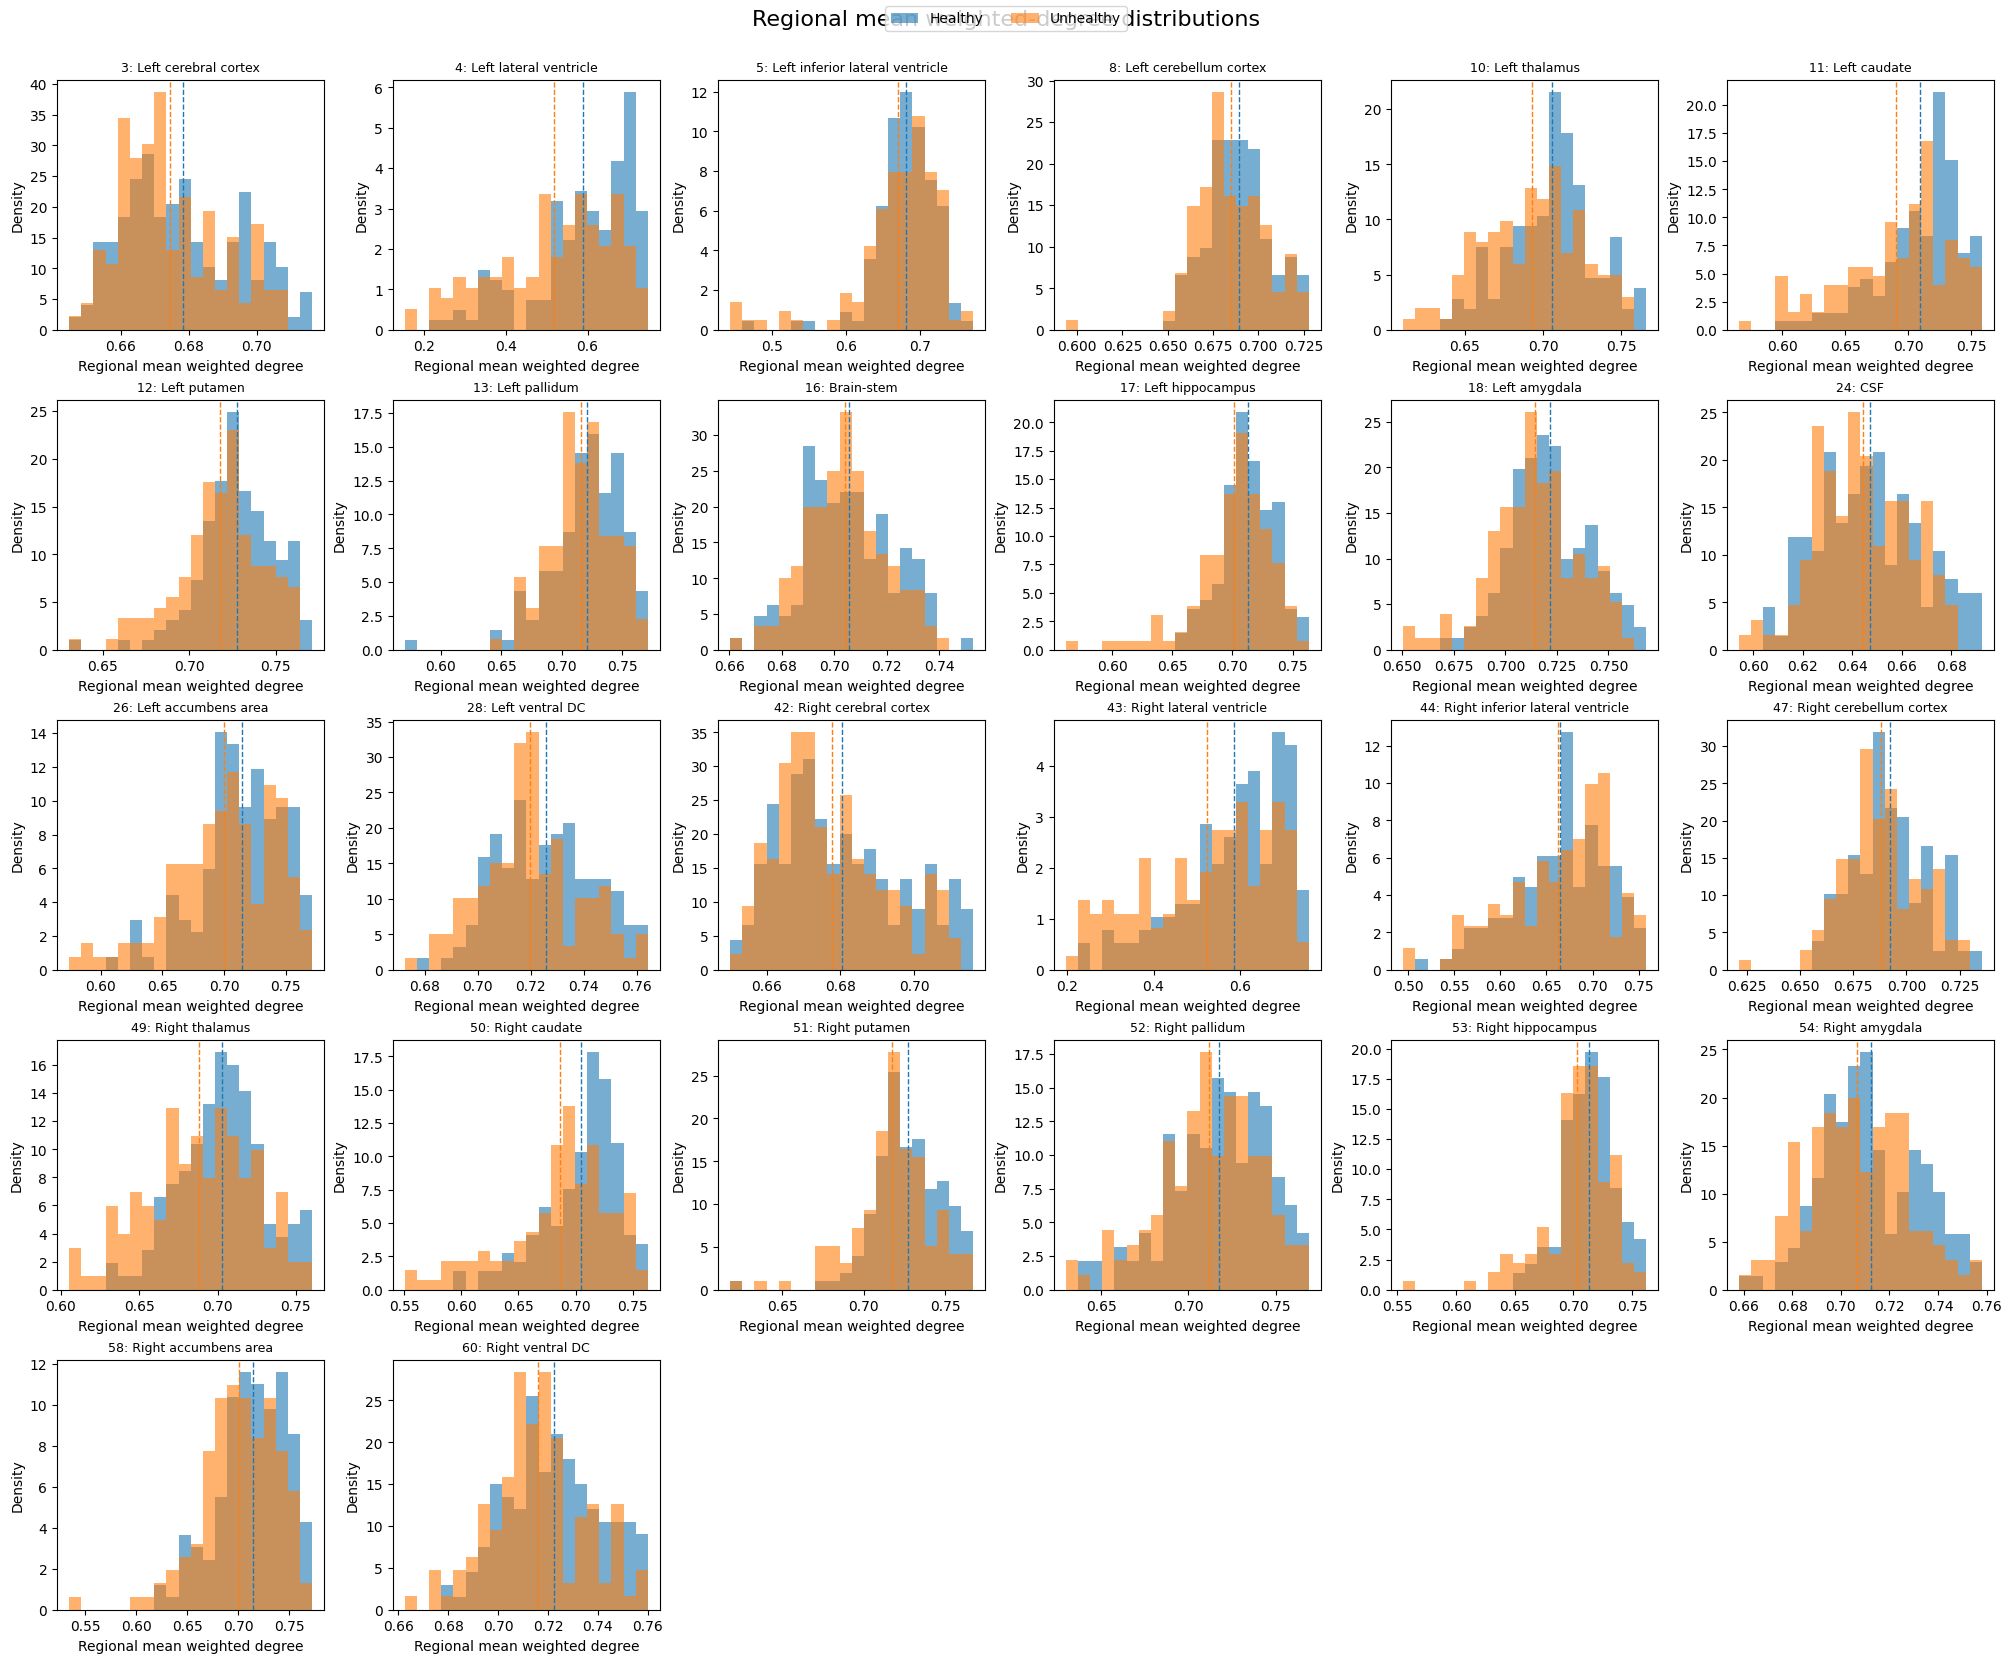

In [15]:
# Plot each ROI distribution of regional mean weighted degree
# using common bins for Healthy and Unhealthy

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    5,
    6,
    figsize=(20, 16),
    constrained_layout=True,
)

axes = axes.flatten()

for axis, roi in zip(axes, rois):
    healthy_values = np.asarray(
        weighted_degree_mean_healthy[roi]
    )

    unhealthy_values = np.asarray(
        weighted_degree_mean_unhealthy[roi]
    )

    label_name = label_lookup.loc[
        label_lookup["label_number"] == roi,
        "label_name",
    ].iloc[0]

    # Use identical bin boundaries for both groups
    combined_values = np.concatenate([
        healthy_values,
        unhealthy_values,
    ])

    common_bins = np.histogram_bin_edges(
        combined_values,
        bins=20,
    )

    axis.hist(
        healthy_values,
        bins=common_bins,
        density=True,
        alpha=0.6,
        color="tab:blue",
        label="Healthy",
    )

    axis.hist(
        unhealthy_values,
        bins=common_bins,
        density=True,
        alpha=0.6,
        color="tab:orange",
        label="Unhealthy",
    )

    axis.axvline(
        np.mean(healthy_values),
        color="tab:blue",
        linestyle="--",
        linewidth=1,
    )

    axis.axvline(
        np.mean(unhealthy_values),
        color="tab:orange",
        linestyle="--",
        linewidth=1,
    )

    axis.set_title(f"{roi}: {label_name}", fontsize=9)
    axis.set_xlabel("Regional mean weighted degree")
    axis.set_ylabel("Density")

# Hide unused panels
for axis in axes[len(rois):]:
    axis.axis("off")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
)

fig.suptitle(
    "Regional mean weighted-degree distributions",
    fontsize=16,
    y=1.03,
)

plt.show()

## Correlation Matrix Between Regions

Display direct regional jacobian means

In [16]:
subjects = selected_healthy + selected_unhealthy
rois = label_lookup["label_number"].astype(int).tolist()

subject_regional_means = pd.DataFrame(
    index=subjects,
    columns=rois,
    dtype=np.float64,
)

# Loop over subjects
for subject_name in subjects:
    subject = subject_dirs[subject_name]

    # Read the means
    means = np.fromfile(
        subject / "direct_mean.dat",
        dtype=np.float64,
    )
    offsets = np.fromfile(
        subject / "parcel_offsets.dat",
        dtype=np.int64,
    )
    parcel_sizes = np.diff(offsets)

    # Read the means and parcel sizes for each ROI
    for row in label_lookup.itertuples(index=False):
        roi = int(row.label_number)
        start = int(row.roi_id_start)
        end = int(row.roi_id_end)

        selected_means = means[start:end + 1]
        selected_sizes = parcel_sizes[start:end + 1]

        
        subject_regional_means.loc[subject_name, roi] = np.average(
            selected_means,
            weights=selected_sizes,
        )

subject_regional_means

,3,4,5,8,10,11,12,13,16,17,...,44,47,49,50,51,52,53,54,58,60
sub-0002,0.003309,0.517629,-0.186121,-0.213271,-0.124135,0.104957,-0.259303,-0.238985,-0.036896,0.009915,...,-0.160046,-0.202350,-0.121673,0.110239,-0.209733,-0.222953,0.004143,0.036672,-0.402668,-0.065781
sub-0003,-0.040931,-0.051949,-0.369440,-0.000104,-0.052407,0.133408,0.121234,-0.077707,0.070696,0.056001,...,-0.490411,-0.018507,-0.057725,0.067573,0.165166,-0.028320,0.073032,0.030880,-0.218853,0.006275
sub-0010,-0.034198,0.456222,-0.257787,0.044018,-0.220933,0.322539,0.024779,-0.004270,0.009225,-0.109458,...,-0.404220,0.035705,-0.163558,0.263247,0.104200,0.038471,-0.053821,-0.098452,-0.279774,-0.001149
sub-0014,-0.000337,-0.487189,-0.354286,-0.034766,-0.111224,-0.020858,-0.104548,-0.069711,0.002957,-0.034756,...,-0.505188,-0.019491,-0.130112,-0.127839,-0.034957,-0.024962,-0.032114,-0.078334,-0.130123,-0.051647
sub-0055,0.012071,0.251839,-0.257332,-0.168909,-0.162215,0.136678,-0.133205,-0.090942,-0.017315,-0.144523,...,-0.118032,-0.144534,-0.160783,0.100304,-0.108186,-0.144416,-0.156198,-0.014128,-0.075340,-0.042397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sub-1405,-0.013828,0.225967,-0.053904,-0.057734,-0.065463,0.194175,0.077090,0.183742,0.072431,0.119205,...,-0.164397,-0.086805,-0.050000,0.088103,0.067266,0.106872,0.098523,0.204789,-0.007371,0.087428
sub-1416,0.054683,0.354660,-0.242786,-0.010812,-0.198958,0.005743,-0.108819,-0.086940,0.019869,-0.135976,...,-0.069148,-0.026100,-0.176360,-0.062043,-0.110667,-0.102441,-0.094976,-0.135289,-0.101646,-0.042707
sub-1424,-0.022373,0.586729,-0.153414,-0.038223,-0.160243,0.153025,0.002011,-0.077938,-0.033040,0.076636,...,-0.138230,-0.041453,-0.175551,0.169411,-0.005358,-0.140918,0.143523,0.112129,-0.235467,-0.012318
sub-1466,0.006671,0.967618,0.621575,-0.226919,-0.246326,0.209134,-0.252112,-0.171239,-0.032320,0.072554,...,0.420345,-0.202993,-0.304829,0.353216,-0.139995,-0.189033,0.027296,0.102820,-0.007902,-0.046674


In [17]:
# Rename the columns to actual ROI names for interpretability
label_lookup_edited = label_lookup.copy()

# Rename Left and Right to L and R 
label_lookup_edited["label_name"] = label_lookup_edited["label_name"].str.replace(
    r"Left", "L", regex=True
).str.replace(
    r"Right", "R", regex=True
)
roi_name_map_edited = (
    label_lookup_edited
    .set_index("label_number")["label_name"]
    .to_dict()
)


# Correlate regions across subjects
means_corr = subject_regional_means.corr(method="pearson")
means_corr = means_corr.rename(
    index=roi_name_map_edited,
    columns=roi_name_map_edited,
)

means_corr

,L cerebral cortex,L lateral ventricle,L inferior lateral ventricle,L cerebellum cortex,L thalamus,L caudate,L putamen,L pallidum,Brain-stem,L hippocampus,...,R inferior lateral ventricle,R cerebellum cortex,R thalamus,R caudate,R putamen,R pallidum,R hippocampus,R amygdala,R accumbens area,R ventral DC
L cerebral cortex,1.000000,-0.471191,-0.372934,-0.102818,0.082058,-0.322852,0.179772,0.088076,-0.162991,-0.163448,...,-0.241970,-0.116560,-0.069592,-0.360648,0.064870,-0.023264,-0.202492,0.073661,0.195428,-0.278912
L lateral ventricle,-0.471191,1.000000,0.545199,-0.249357,-0.402953,0.511180,-0.478010,-0.338891,-0.285054,0.146955,...,0.470360,-0.236647,-0.281938,0.501875,-0.422202,-0.341815,0.124213,-0.153118,-0.309291,-0.100610
L inferior lateral ventricle,-0.372934,0.545199,1.000000,-0.068961,-0.061982,0.386446,-0.222911,-0.064259,-0.037594,0.567249,...,0.787618,-0.040208,-0.000101,0.448846,-0.160601,-0.058165,0.510395,0.128601,-0.049212,0.243595
L cerebellum cortex,-0.102818,-0.249357,-0.068961,1.000000,0.263442,-0.006489,0.347312,0.260373,0.527508,0.154769,...,-0.068987,0.956435,0.302235,-0.060108,0.352769,0.325823,0.223137,0.096513,0.154961,0.437887
L thalamus,0.082058,-0.402953,-0.061982,0.263442,1.000000,0.007386,0.525957,0.517174,0.457670,0.188705,...,-0.136832,0.311077,0.848189,0.019163,0.445470,0.500945,0.218186,0.162518,0.391733,0.427067
L caudate,-0.322852,0.511180,0.386446,-0.006489,0.007386,1.000000,0.144149,0.136234,-0.030628,0.208859,...,0.374757,-0.008298,0.010963,0.873704,0.158880,0.130124,0.202180,0.004536,0.057461,0.065823
L putamen,0.179772,-0.478010,-0.222911,0.347312,0.525957,0.144149,1.000000,0.586378,0.362319,0.142209,...,-0.168960,0.353351,0.454127,0.105747,0.920634,0.605962,0.140892,0.219932,0.463174,0.284009
L pallidum,0.088076,-0.338891,-0.064259,0.260373,0.517174,0.136234,0.586378,1.000000,0.422624,0.085579,...,-0.099615,0.296402,0.388666,0.136716,0.533762,0.809572,0.108324,0.143577,0.355378,0.328459
Brain-stem,-0.162991,-0.285054,-0.037594,0.527508,0.457670,-0.030628,0.362319,0.422624,1.000000,0.172275,...,-0.079335,0.542555,0.450429,-0.018207,0.365757,0.461888,0.208792,0.069883,0.242944,0.677786
L hippocampus,-0.163448,0.146955,0.567249,0.154769,0.188705,0.208859,0.142209,0.085579,0.172275,1.000000,...,0.438753,0.179217,0.207817,0.207783,0.160313,0.124743,0.868948,0.493948,0.192520,0.400978


In [18]:
# Rename ROI columns
subject_regional_means_named = subject_regional_means.rename(
    columns=roi_name_map_edited
)

# Calculate correlations separately by group
healthy_corr = (
    subject_regional_means_named
    .loc[selected_healthy]
    .corr(method="pearson")
)

unhealthy_corr = (
    subject_regional_means_named
    .loc[selected_unhealthy]
    .corr(method="pearson")
)

# Descriptive difference
corr_difference = unhealthy_corr - healthy_corr

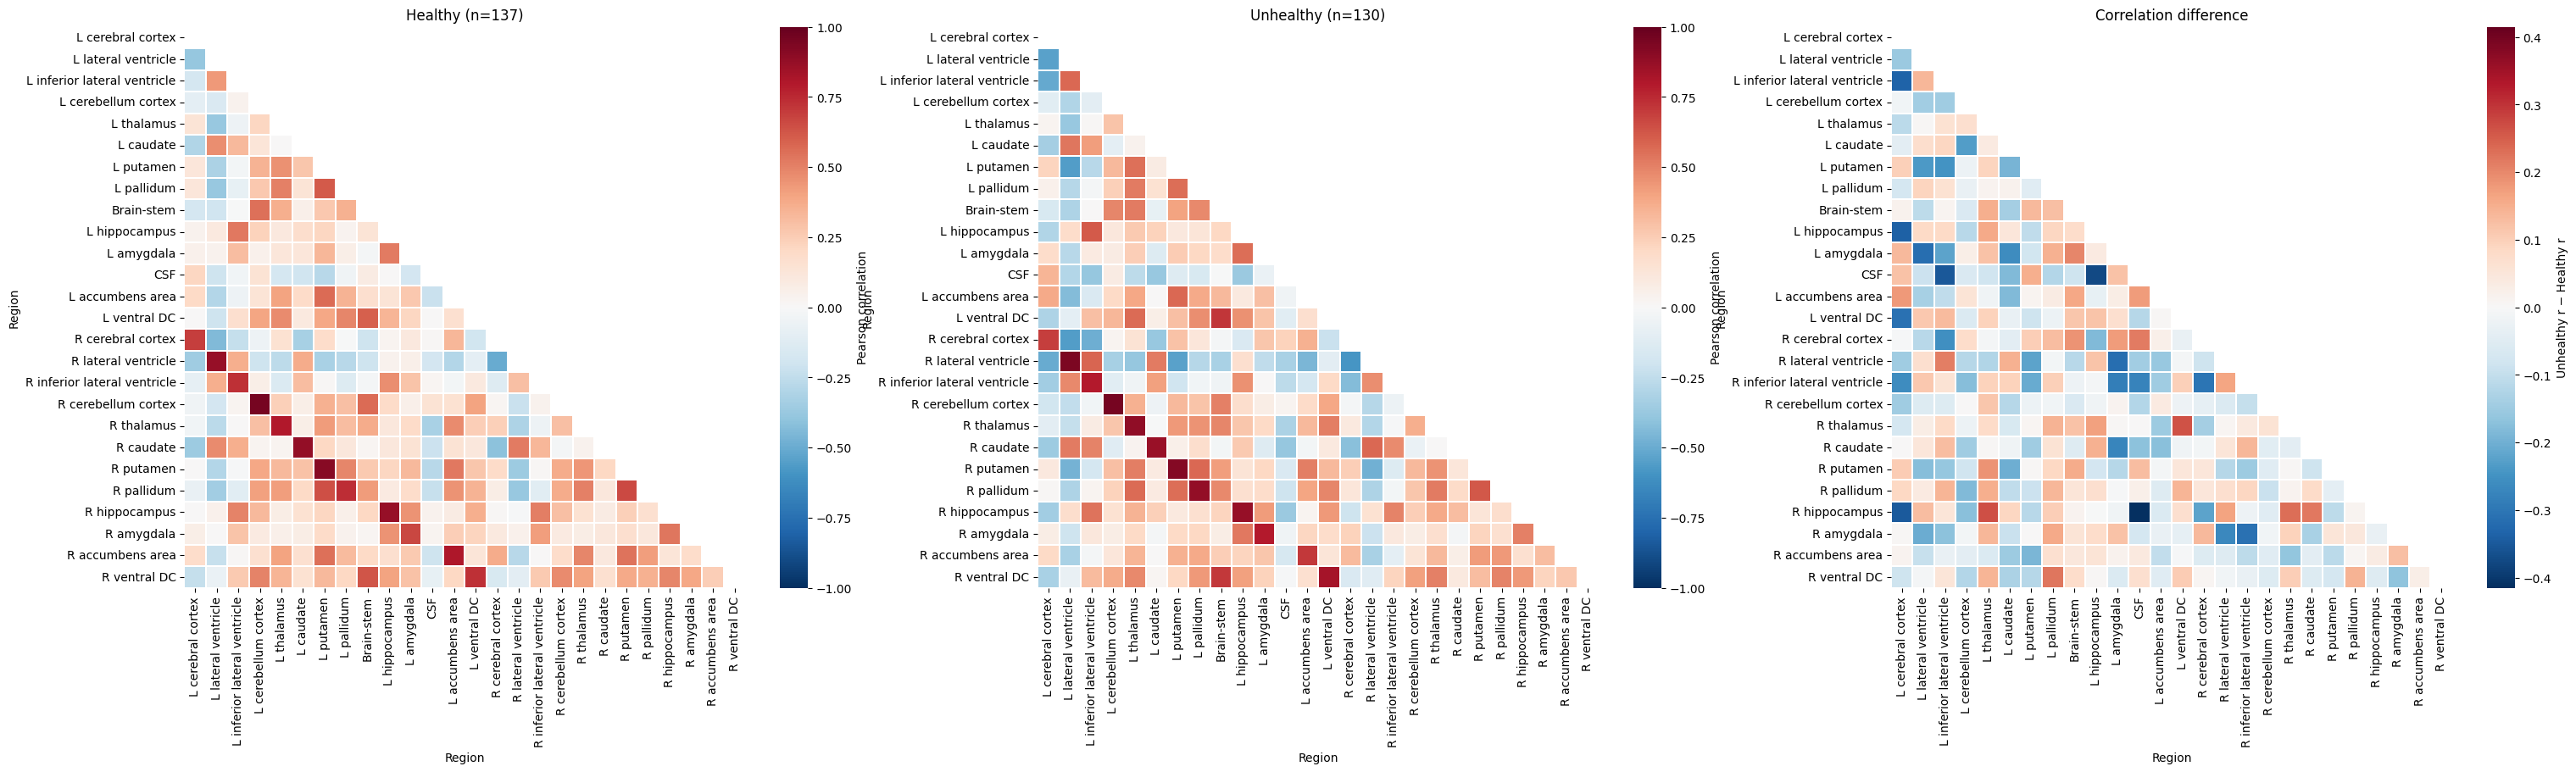

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Maximum absolute difference for a symmetric difference color scale
difference_limit = np.nanmax(
    np.abs(corr_difference.to_numpy())
)

# Hide the upper triangle and diagonal
triangle_mask = np.triu(
    np.ones_like(healthy_corr, dtype=bool),
    k=0,
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(30, 9),
    constrained_layout=True,
)

# Healthy participants
sns.heatmap(
    healthy_corr,
    mask=triangle_mask,
    ax=axes[0],
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.25,
    cbar_kws={"label": "Pearson correlation"},
)
axes[0].set_title(f"Healthy (n={len(selected_healthy)})")

# Unhealthy participants
sns.heatmap(
    unhealthy_corr,
    mask=triangle_mask,
    ax=axes[1],
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.25,
    cbar_kws={"label": "Pearson correlation"},
)
axes[1].set_title(f"Unhealthy (n={len(selected_unhealthy)})")

# Unhealthy-minus-healthy correlation difference
sns.heatmap(
    corr_difference,
    mask=triangle_mask,
    ax=axes[2],
    cmap="RdBu_r",
    vmin=-difference_limit,
    vmax=difference_limit,
    center=0,
    square=True,
    linewidths=0.25,
    cbar_kws={"label": "Unhealthy r − Healthy r"},
)
axes[2].set_title("Correlation difference")

for axis in axes:
    axis.set_xlabel("Region")
    axis.set_ylabel("Region")
    axis.tick_params(axis="x", rotation=90)
    axis.tick_params(axis="y", rotation=0)

plt.show()